# 기초데이터과학 (01분반)

## 06-1. 데이터 정제

### Acknowledgement
#### 이 자료는 다음 서적의 내용을 바탕으로 작성되었음

- 쉽게 배우는 파이썬 데이터 분석. 이지스 퍼블리싱
- 파이썬 라이브러리를 활용한 데이터 분석. 한빛미디어

### 데이터 정제 (Data cleansing)
- 데이터에 존재하는 결측값이나 이상값 등을 처리하여 데이터의 신뢰도를 높이고 데이터 분석에 사용될 수 있도록 하는 작업
- 데이터 분석 전에 필요한 데이터 전처리 과정 중 하나

#### 데이터 오류 원인
- 결측값/결측치 (missing value)
  - 데이터가 입력되지 않고 누락된 값, 비어 있는 값
  - NaN, Na, Null, None 등으로 표현
  - 결측치가 많으면 데이터 분석 시 함수가 적용되지 않거나 분석 결과가 왜곡되는 문제 발생
- 이상값/이상치
  - 정상 범위에서 벗어난 값을 통칭
  - 데이터 수집 과정의 오류로 포함될 수 있으며, 그대로 분석에 사용하면 결과가 왜곡될 수 있음
  - 이상치는 다시 두 가지로 나눌 수 있음
    - **존재할 수 없는 값**: 점수가 -10점이나 1000점인 경우처럼 논리적으로 불가능한 값
    - **극단치 (outlier)**: 존재할 수는 있지만 다른 값들에 비해 극단적으로 크거나 작은 값

#### 데이터 정제 방법
- 삭제: 정제가 필요한 데이터의 부분/전체 삭제
- 대체: 오류 데이터를 평균, 최빈값, 중앙값 등으로 대체
- 예측값 삽입: 회귀식 등을 이용해 예측값을 삽입

##### 데이터 정제 시 유의점
- 데이터 정제 후 데이터 활용 시 데이터 혹은 데이터 분석 결과에 왜곡이 발생하지 않도록 세심한 고려가 필요

#### 결측치가 존재하는 예제 데이터 만들기
- 결측치: numpy의 numpy.nan 이용

In [1]:
# 예제 데이터 만들기
import pandas as pd
import numpy as np

test = pd.DataFrame({'id'      : [1, 2, 3, 4, 5, 6, 7],
                      'midterm' : [60, 80, 70, 90, 85, np.nan, 75],
                       'final' : [70, 83, 65, 95, 80, 90, np.nan]})

print(test)

   id  midterm  final
0   1     60.0   70.0
1   2     80.0   83.0
2   3     70.0   65.0
3   4     90.0   95.0
4   5     85.0   80.0
5   6      NaN   90.0
6   7     75.0    NaN


#### 결측치 존재 여부 확인하기
- isnull(), isna(), notnull() 함수

In [2]:
print(test.isnull())

      id  midterm  final
0  False    False  False
1  False    False  False
2  False    False  False
3  False    False  False
4  False    False  False
5  False     True  False
6  False    False   True


In [3]:
print(test.isna())

      id  midterm  final
0  False    False  False
1  False    False  False
2  False    False  False
3  False    False  False
4  False    False  False
5  False     True  False
6  False    False   True


In [4]:
print(test.notnull())

     id  midterm  final
0  True     True   True
1  True     True   True
2  True     True   True
3  True     True   True
4  True     True   True
5  True    False   True
6  True     True  False


##### 결측치 개수 확인하기

In [5]:
print(test.isnull().sum())

id         0
midterm    1
final      1
dtype: int64


In [6]:
print(test.isna().sum())

id         0
midterm    1
final      1
dtype: int64


##### 결측치가 있는 데이터 행 확인하기

In [7]:
na = test['midterm'].isna() # midterm 컬럼에서 결측치가 있는 것은 True, 그렇지 않으면 False
print(na)

missing = test[na]
print(missing)

0    False
1    False
2    False
3    False
4    False
5     True
6    False
Name: midterm, dtype: bool
   id  midterm  final
5   6      NaN   90.0


In [8]:
missing = test[test['final'].isna()]
print(missing)

   id  midterm  final
6   7     75.0    NaN


#### 결측치 제거하기
- dropna() 함수 이용

- pandas.DataFrame.dropna(axis=0, how='any', inplace=False, subset=None)
  - axis=0: 결측치를 포함한 행 삭제
  - axis=1: 결측치를 포함한 열 삭제
  - how='any': 결측치가 하나라도 포함되면 제거
  - how='all': 행 또는 열 모두가 결측치여야 제거
  - inplace=True: 원본 데이터에서 결측치 삭제
  - inplace=False: 원본은 그대로 두고 결측치가 삭제된 데이터프레임 반환
  - subset: 결측치를 제거할 변수(열)
- 원본을 바꾸고 싶을 때는 `inplace=True` 보다 **결과를 다시 할당하는 방식**을 권장
  - 예: `test = test.dropna()`
  - 메소드 체이닝과 함께 쓸 수 있고, 어느 줄에서 데이터가 바뀌었는지 드러나기 때문

In [9]:
d = test.dropna() # 기본값이 axis=0, how='any'이므로 결측치가 하나라도 있는 행은 모두 삭제된 데이터프레임 반환
print(d) 

   id  midterm  final
0   1     60.0   70.0
1   2     80.0   83.0
2   3     70.0   65.0
3   4     90.0   95.0
4   5     85.0   80.0


In [10]:
print(test.dropna(how='all')) # axis=0, how='all'이므로 행의 모두가 결측치여야 제거되므로 행의 하나의 변수만 NaN인 행은 모두 남아 있음

   id  midterm  final
0   1     60.0   70.0
1   2     80.0   83.0
2   3     70.0   65.0
3   4     90.0   95.0
4   5     85.0   80.0
5   6      NaN   90.0
6   7     75.0    NaN


In [11]:
print(test.dropna(axis=1)) # axis=1, how='any'이므로 결측치가 하나라도 있는 열은 모두 삭제됨

   id
0   1
1   2
2   3
3   4
4   5
5   6
6   7


In [12]:
print(test.dropna(subset=['final'])) # final 변수에서 결측치가 있는 행만 삭제됨

   id  midterm  final
0   1     60.0   70.0
1   2     80.0   83.0
2   3     70.0   65.0
3   4     90.0   95.0
4   5     85.0   80.0
5   6      NaN   90.0


In [13]:
print(test.dropna(subset=['midterm'])) # midterm 변수에서 결측치가 있는 행만 삭제됨

   id  midterm  final
0   1     60.0   70.0
1   2     80.0   83.0
2   3     70.0   65.0
3   4     90.0   95.0
4   5     85.0   80.0
6   7     75.0    NaN


In [14]:
print(test.dropna(subset=['midterm', 'final'])) # midterm 변수와 final 변수에서 결측치가 있는 행 삭제

   id  midterm  final
0   1     60.0   70.0
1   2     80.0   83.0
2   3     70.0   65.0
3   4     90.0   95.0
4   5     85.0   80.0


- `dropna( )` 사용하지 않고 `notnull( )` 조건으로 결측 행 제거하는 것도 가능

In [15]:
# notnull( ) 조건으로 거르기
# null이 아닌 것만 추출하는 방식
a = test[test['midterm'].notnull() & test['final'].notnull()]

# dropna( ) 사용
b = test.dropna(subset = ['midterm', 'final'])

print(a)
print()
print("두 결과가 같은가?", a.equals(b))

   id  midterm  final
0   1     60.0   70.0
1   2     80.0   83.0
2   3     70.0   65.0
3   4     90.0   95.0
4   5     85.0   80.0

두 결과가 같은가? True


#### 결측치 대체하기
- 데이터가 크고 결측치가 얼마 없을 때는 결측치를 제거하고 분석하더라도 큰 무리가 없음
- 데이터가 작고 결측치가 많을 때는 결측치를 제거하면 너무 많은 데이터가 손실되어 분석 결과가 왜곡될 수 있음
- 이러한 문제를 보완하기 위해 결측치를 다른 값으로 채워 넣는 결측치 대체 방법을 사용함

##### 결측치 대체 방법
- 평균값이나 최빈값 같은 대표값을 구해 모든 결측치를 하나의 값으로 일괄 대체하는 방법
- 통계 분석 기법으로 결측치의 예측값을 추정해 대체하는 방법

##### 평균값으로 결측치 대체하기
- fillna() 함수 이용

In [16]:
print(test)

   id  midterm  final
0   1     60.0   70.0
1   2     80.0   83.0
2   3     70.0   65.0
3   4     90.0   95.0
4   5     85.0   80.0
5   6      NaN   90.0
6   7     75.0    NaN


In [17]:
# midterm 변수의 평균값 계산
mid_mean = test['midterm'].mean() # mean(), sum() 등 수치 연산 함수는 결측치가 있으면 자동으로 제외하고 연산하는 기능이 있음
print(mid_mean)

76.66666666666667


In [18]:
# midterm 변수의 평균값으로 NaN 값을 대체
test['midterm'] = test['midterm'].fillna(mid_mean)   # 계산한 값을 숫자로 옮겨 적지 말고 변수를 그대로 사용

print(test)

   id    midterm  final
0   1  60.000000   70.0
1   2  80.000000   83.0
2   3  70.000000   65.0
3   4  90.000000   95.0
4   5  85.000000   80.0
5   6  76.666667   90.0
6   7  75.000000    NaN


- 평균값을 `76.7` 처럼 **숫자로 직접 옮겨 적지 말 것**
  - 실제 평균은 76.666... 이므로 값이 달라짐
  - 데이터가 바뀌면 평균도 바뀌는데, 숫자를 적어 두면 코드를 일일이 고쳐야 함
  - 계산한 결과를 변수에 담아 그대로 사용하는 것이 안전함

In [19]:
print(test['midterm'].isna().sum()) # midterm 변수의 결측치 값의 개수가 0인 것을 확인할 수 있음

0


In [20]:
# final 변수의 결측치를 final 변수의 평균값으로 대체하기

f_mean = test['final'].mean() 
print(f_mean)

test['final'] = test['final'].fillna(f_mean)
print(test)

80.5
   id    midterm  final
0   1  60.000000   70.0
1   2  80.000000   83.0
2   3  70.000000   65.0
3   4  90.000000   95.0
4   5  85.000000   80.0
5   6  76.666667   90.0
6   7  75.000000   80.5


##### 중앙값으로 결측치 대체하기
- 평균은 **이상치에 크게 영향을 받음**
  - 값 하나가 매우 크거나 작으면 평균이 그쪽으로 끌려감
- 중앙값은 값들을 크기순으로 늘어놓았을 때 가운데 값이므로 이상치의 영향을 거의 받지 않음
- 데이터에 이상치가 있을 가능성이 있다면 **중앙값으로 대체하는 편이 안전**함

In [21]:
s = pd.Series([60, 70, 75, 80, 1000])   # 1000 은 입력 오류로 생긴 이상치

print("평균  :", s.mean())     # 이상치에 끌려감
print("중앙값:", s.median())   # 영향을 거의 받지 않음

평균  : 257.0
중앙값: 75.0


- 평균 257점은 어느 학생의 점수와도 거리가 먼 값임
- 이 값으로 결측치를 채우면 오히려 데이터를 더 왜곡하게 됨
- 뒤에서 다룰 이상치 처리와 연결되는 내용이므로 기억해 둘 것

#### 연습문제
- mpg 데이터에 결측치를 추가하여 결측치 확인과 제거 연습을 해보자.
  - mpg 데이터는 미국 환경 보호국에서 공개한 데이터로 1999~2008년 미국에 출시된 자동차 234 종의 정보를 담고 있음


In [51]:
mpg = pd.read_csv('mpg.csv')

# 파일이 없다면 아래 두 줄의 주석을 해제하여 사용
# url = 'https://raw.githubusercontent.com/skang-koreatech/BasicDataScience_2026-2/main/mpg.csv'
# mpg = pd.read_csv(url)

print(mpg.head())

  manufacturer model  displ  year  cyl       trans drv  cty  hwy fl category
0         audi    a4    1.8  1999    4    auto(l5)   f   18   29  p  compact
1         audi    a4    1.8  1999    4  manual(m5)   f   21   29  p  compact
2         audi    a4    2.0  2008    4  manual(m6)   f   20   31  p  compact
3         audi    a4    2.0  2008    4    auto(av)   f   21   30  p  compact
4         audi    a4    2.8  1999    6    auto(l5)   f   16   26  p  compact


In [52]:
# mpg 데이터의 결측치 개수 확인
print(mpg.isna().sum())

manufacturer    0
model           0
displ           0
year            0
cyl             0
trans           0
drv             0
cty             0
hwy             0
fl              0
category        0
dtype: int64


In [53]:
# 결측치 추가하기
mpg.loc[[64, 123, 130, 152, 211], 'hwy'] = np.nan # mpg 데이터의 인덱스 64, 123, 130, 152, 211 행의 hwy 변수의 값을 NaN으로 변경

In [54]:
print(mpg[mpg['hwy'].isna()])

    manufacturer                model  displ  year  cyl       trans drv  cty  \
64         dodge  ram 1500 pickup 4wd    4.7  2008    8  manual(m6)   4   12   
123         jeep   grand cherokee 4wd    3.7  2008    6    auto(l5)   4   15   
130   land rover          range rover    4.0  1999    8    auto(l4)   4   11   
152       nissan       pathfinder 4wd    4.0  2008    6    auto(l5)   4   14   
211   volkswagen                  gti    2.8  1999    6  manual(m5)   f   17   

     hwy fl category  
64   NaN  r   pickup  
123  NaN  r      suv  
130  NaN  p      suv  
152  NaN  p      suv  
211  NaN  r  compact  


1. drv(구동 방식) 별로 hwy(고속도로 연비) 평균이 어떻게 다른지 알아보려고 합니다. 분석을 하기 전에 우선 두 변수에 결측치가 있는지 확인해야 합니다. drv 변수와 hwy 변수에 결측치가 몇 개 있는지 확인해보세요.

2. dropna() 함수를 이용해 hwy 변수의 결측치를 제거하고, groupby() 함수와 agg() 함수를 이용하여 어떤 구동 방식(drv)이 고속도로 연비(hwy) 평균이 높은지 알아보세요.

#### 이상치 정제하기
- 이상치: 정상 범위에서 크게 벗어난 값 혹은 논리적으로 존재할 수 없는 값
- 이상치 정제 방법
  - 이상치 확인
  - 이상치를 결측 처리
  - 결측치 제거 혹은 대체

#### 이상치 제거하기 - 논리적으로 존재할 수 없는 값
##### 존재할 수 없는 값이 존재하는 예제 데이터 만들기

In [27]:
# 예제 데이터 만들기
import pandas as pd
import numpy as np

test = pd.DataFrame({'id'      : [1, 2, 300, 4, 5, 6, 7],
                      'midterm' : [60, -10, 70, 90, 85, 1000, 75],
                       'final' : [70, 83, 65, 95, 80, 90, 9000]})

print(test)

    id  midterm  final
0    1       60     70
1    2      -10     83
2  300       70     65
3    4       90     95
4    5       85     80
5    6     1000     90
6    7       75   9000


- 가정
  - 학생 수가 10명이어서 id는 1부터 10까지만 존재한다.
  - 점수는 100점 만점이고 0부터 100까지만 나올 수 있다.

##### 이상치 확인하기
- df.value_counts() 함수를 이용해 빈도표를 만들어 확인

In [28]:
print(test['id'].value_counts()) # id 열의 각 값의 개수를 계산

id
1      1
2      1
300    1
4      1
5      1
6      1
7      1
Name: count, dtype: int64


- sort_index() 함수를 사용하면 인덱스 열을 기준으로 정렬 가능

In [29]:
print(test['id'].value_counts().sort_index()) # sort_index() 함수로 인덱스 열을 기준으로 정렬

id
1      1
2      1
4      1
5      1
6      1
7      1
300    1
Name: count, dtype: int64


In [30]:
print(test['midterm'].value_counts().sort_index()) # midterm 열의 각 값의 개수를 계산하고 midterm 값의 오름차순으로 정렬

midterm
-10      1
 60      1
 70      1
 75      1
 85      1
 90      1
 1000    1
Name: count, dtype: int64


In [31]:
print(test['final'].value_counts().sort_index()) # final 열의 각 값의 개수를 계산하고 final 값의 오름차순으로 정렬

final
65      1
70      1
80      1
83      1
90      1
95      1
9000    1
Name: count, dtype: int64


- 위의 결과에서 id에 존재할 수 없는 값인 300이 하나 존재하고, 
- midterm에 존재할 수 없는 -10, 1000이 하나씩 존재하고, 
- final에 존재할 수 없는 9000이 하나 존재함을 알 수 있음

##### 결측 처리하기
- 변수에 이상치가 들어 있음을 확인하면 이상치를 결측치로 바꿈
- np.where() 함수를 이용하여 이상치일 경우 NaN을 값으로 할당

In [32]:
test['id'] = np.where(test['id'] == 300, np.nan, test['id']) # id 값이 300이면 nan으로 값을 할당하고 그렇지 않으면 원래 id 값을 할당
print(test)

    id  midterm  final
0  1.0       60     70
1  2.0      -10     83
2  NaN       70     65
3  4.0       90     95
4  5.0       85     80
5  6.0     1000     90
6  7.0       75   9000


- `id` 값이 `1, 2, 3...` 에서 `1.0, 2.0, 3.0...` 으로 바뀐 것에 주목할 것
  - `NaN` 은 실수로만 표현할 수 있으므로, 결측치가 하나라도 들어가면 열 전체가 실수형으로 바뀜
  - 5주차 `concat( )` 예제에서 `bonus` 열이 `float64` 로 바뀐 것과 같은 현상

In [33]:
# midterm 값이 100보다 크거나 0보다 작으면 nan 값으로 할당, 그렇지 않으면 원래 값을 할당
test['midterm'] = np.where(test['midterm'] > 100, np.nan, test['midterm'])
test['midterm'] = np.where(test['midterm'] < 0, np.nan, test['midterm'])

# final 값이 100보다 크면 nan 값으로 할당, 그렇지 않으면 원래 값을 할당
test['final'] = np.where(test['final'] > 100, np.nan, test['final'])

print(test)

    id  midterm  final
0  1.0     60.0   70.0
1  2.0      NaN   83.0
2  NaN     70.0   65.0
3  4.0     90.0   95.0
4  5.0     85.0   80.0
5  6.0      NaN   90.0
6  7.0     75.0    NaN


- df.dropna() 함수를 이용하여 결측치를 제거

In [35]:
clean_test = test.dropna() # 결측치가 하나라도 있는 행은 삭제

print(clean_test)

    id  midterm  final
0  1.0     60.0   70.0
3  4.0     90.0   95.0
4  5.0     85.0   80.0


##### __참고__ - 문자열과 결측치를 함께 넣는 경우
- `np.where( )` 로 문자열 값과 `np.nan` 을 섞어서 넣으려 하면 **오류가 발생**함
  - 문자열과 실수는 하나의 배열 안에서 같은 자료형으로 맞출 수 없기 때문
- 아래 셀을 실행하여 확인할 것

In [36]:
df = pd.DataFrame({'x1': [1, 1, 2, 2]})
print(df)
print()

try:
    df['x2'] = np.where(df['x1'] == 1, 'a', np.nan)   # 문자열 'a' 와 np.nan 을 섞음
except Exception as e:
    print("오류 발생:", type(e).__name__)

   x1
0   1
1   1
2   2
3   2

오류 발생: DTypePromotionError


- 해결 방법 1: `np.nan` 대신 `None` 사용
  - `None` 은 pandas 에서 결측치로 인식됨

In [37]:
df['x2'] = np.where(df['x1'] == 1, 'a', None)

print(df)
print()
print(df.isna())   # x2 에서 None 이 들어간 자리가 True

   x1    x2
0   1     a
1   1     a
2   2  None
3   2  None

      x1     x2
0  False  False
1  False  False
2  False   True
3  False   True


- 해결 방법 2: 우선 임시 문자열을 넣은 뒤 `replace( )` 로 `np.nan` 으로 바꿈

In [38]:
df['x3'] = np.where(df['x1'] == 1, 'a', 'etc')   # 결측으로 만들 자리에 우선 'etc' 할당
df['x3'] = df['x3'].replace('etc', np.nan)        # 'etc' 를 np.nan 으로 대체

print(df)
print()
print(df.isna())

   x1    x2   x3
0   1     a    a
1   1     a    a
2   2  None  NaN
3   2  None  NaN

      x1     x2     x3
0  False  False  False
1  False  False  False
2  False   True   True
3  False   True   True


- 참고로 NumPy 1.x 버전에서는 이 경우 오류 없이 문자열 `'nan'` 이 조용히 들어가 결측치로 인식되지 않는 문제가 있었음
  - 인터넷의 예전 예제 코드에서 이런 설명을 볼 수 있으나, 현재 버전에서는 오류로 바뀌었음

#### 이상치 제거하기 - 극단적인 값
- 논리적으로 존재할 수 있지만 극단적으로 크거나 작은 값을 **극단치(outlier)** 라고 함
  - 예를 들어, 몸무게 변수에 200kg 이상의 값이 있다면, 존재할 가능성은 있지만 매우 드문 경우이므로 극단치라고 볼 수 있음
  - 데이터에 극단치가 있으면 분석 결과가 왜곡될 수 있으므로 분석하기 전에 제거
- 극단치를 제거하려면 먼저 어디까지를 정상 범위로 볼 것인지 정해야 함
  - 쉬운 방법은 논리적으로 판단해 정하는 것. 예를 들어 성인의 몸무게가 40~150kg을 벗어나는 경우는 매우 드물다고 판단하고 이 범위를 벗어나면 극단치로 간주
  - 두번째 방법은 통계적인 기준을 이용하는 것. 예를 들어 상하위 0.3% 또는 +3 혹은 -3 표준편차에 해당할 만큼 극단적으로 크거나 작으면 극단치로 간주

##### 상자 그림(box plot)으로 극단치 기준 정하기
- 상자 그림: 데이터의 분포를 직사각형의 상자 모양으로 표현한 그래프
  - 상자 그림을 보면 데이터의 분포를 한눈에 파악하기 쉬움
  - 상자 그림은 중심에서 멀리 떨어진 값을 점으로 표현하는데, 이를 이용해 극단치의 기준을 정할 수 있음

##### 1. 상자 그림 살펴보기
- mpg 데이터의 hwy 변수로 상자 그림 생성

<Axes: ylabel='hwy'>

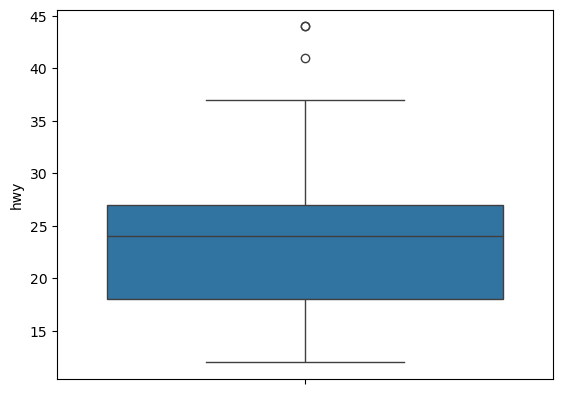

In [39]:
mpg = pd.read_csv('mpg.csv')

# 파일이 없다면 아래 두 줄의 주석을 해제하여 사용
# url = 'https://raw.githubusercontent.com/skang-koreatech/BasicDataScience_2026-2/main/mpg.csv'
# mpg = pd.read_csv(url)

import seaborn as sns # seaborn 패키지를 이용하여 시각화하는 것을 추후 수업에서 다룰 것임
sns.boxplot(data = mpg, y = 'hwy')


- 상자 밑면 (1사분위수: Q1)
  - 하위 25% 위치 값

- 상자 내 굵은 선 (2사분위수: Q2)
  - 하위 50% 위치 값 (중앙값)

- 상자 윗면 (3사분위수: Q3)
  - 하위 75% 위치 값

- IQR (Inter-Quartile Range)
  - 1사분위수와 3사분위수 사이의 거리 (Q3 - Q1). 상자의 높이에 해당

- 상자 위아래 세로선 (수염)
  - 먼저 상자 양 끝에서 1.5 IQR 떨어진 지점에 **보이지 않는 경계선**을 정함
  - 수염은 그 경계선 안쪽에 있는 **실제 데이터 값 중 가장 먼 값**까지 그어짐
    - 경계선 자체까지 그어지는 것이 아님
  - 경계선 밖에 값이 없으면 수염은 데이터의 최소값/최대값까지 이어짐

- 상자 밖 점 표식 (극단치)
  - 1.5 IQR 범위를 벗어난 값
  - 즉, 1.5 IQR 경계선 밖의 값은 점으로 표시되며, 이것이 극단치임

- 위 그림의 경우
  - 위쪽 경계선은 40.5 이지만, 그 안쪽 최대값이 37 이므로 윗수염은 37 에서 끝나고, 그 위의 41, 44 는 점으로 표시됨
  - 윗수염이 데이터의 최댓값(44)까지 이어지지 않는다는 점에 주의
  - 아래쪽 경계선은 4.5 이며, 최솟값 12 가 그 안쪽에 있으므로 아랫수염은 12 까지 이어짐

##### 2. 극단치 기준값 구하기
- 1사분위수, 3사분위수 구하기
  - df.quantile() 함수 이용

In [40]:
pct25 = mpg['hwy'].quantile(0.25) # 1사분위수
print(pct25)

18.0


In [41]:
pct75 = mpg['hwy'].quantile(0.75) # 3사분위수
print(pct75)

27.0


- IQR 구하기

In [42]:
iqr = pct75 - pct25
print(iqr)

9.0


- 하한, 상한 (경계선) 구하기
  - 하한: 1사분위수보다 IQR의 1.5배만큼 더 작은 값
  - 상한: 3사분위수보다 IQR의 1.5배만큼 더 큰 값

In [43]:
low_limit = pct25 - 1.5 * iqr # 하한

print(low_limit)

4.5


In [44]:
up_limit = pct75 + 1.5 * iqr # 상한

print(up_limit)

40.5


##### 3. 극단치를 결측 처리하기

In [45]:
# hwy 값이 하한보다 작거나 상한보다 크면 NaN 할당, 그렇지 않으면 원래 값 할당
mpg['hwy'] = np.where((mpg['hwy'] < low_limit) | (mpg['hwy'] > up_limit), np.nan, mpg['hwy'])

# 결측치 빈도 확인
print(mpg['hwy'].isna().sum())

3


##### 4. 결측치 제거하고 분석하기

In [46]:
# 결측치 제거
# drv 별 분리
# hwy 평균 구하기
d = mpg.dropna(subset = ['hwy']) \
    .groupby('drv') \
    .agg(mean_hwy = ('hwy', 'mean'))  

print(d)

      mean_hwy
drv           
4    19.174757
f    27.728155
r    21.000000


In [47]:
# 결측치 제거 전 원 데이터의 경우 분석 결과 
mpg = pd.read_csv('mpg.csv')

# 파일이 없다면 아래 두 줄의 주석을 해제하여 사용
# url = 'https://raw.githubusercontent.com/skang-koreatech/BasicDataScience_2026-2/main/mpg.csv'
# mpg = pd.read_csv(url)
d2 = mpg.groupby('drv') \
        .agg(mean_hwy = ('hwy', 'mean')) 

print(d2)

      mean_hwy
drv           
4    19.174757
f    28.160377
r    21.000000


#### 연습문제
- mpg 데이터에 이상치를 추가하여 연습을 해보자.
  - drv(구동 방식) 변수의 값은 4(사륜구동), f(전륜구동), r(후륜구동) 세 종류임
  - 몇 개의 행에 존재할 수 없는 값 k를 할당하고 cty(도시 연비) 변수도 몇 개의 행에 극단적으로 크거나 작은 값을 할당하여 이상치 생성

In [57]:
mpg = pd.read_csv('mpg.csv')

# 파일이 없다면 아래 두 줄의 주석을 해제하여 사용
# url = 'https://raw.githubusercontent.com/skang-koreatech/BasicDataScience_2026-2/main/mpg.csv'
# mpg = pd.read_csv(url)

print(mpg.describe())

            displ         year         cyl         cty         hwy
count  234.000000   234.000000  234.000000  234.000000  234.000000
mean     3.471795  2003.500000    5.888889   16.858974   23.440171
std      1.291959     4.509646    1.611534    4.255946    5.954643
min      1.600000  1999.000000    4.000000    9.000000   12.000000
25%      2.400000  1999.000000    4.000000   14.000000   18.000000
50%      3.300000  2003.500000    6.000000   17.000000   24.000000
75%      4.600000  2008.000000    8.000000   19.000000   27.000000
max      7.000000  2008.000000    8.000000   35.000000   44.000000


In [58]:
mpg.loc[[9, 13, 57, 92], 'drv'] = 'k' # 데이터의 9, 13, 57, 92 인덱스 행의 drv 변수 값을 'k'로 할당
mpg.loc[[28, 42, 128, 202], 'cty'] = [3, 4, 39, 42] # 데이터의 28, 42, 128, 202 인덱스 행의 cty 변수 값을 3, 4, 39, 42로 할당

print(mpg.loc[5:15, ['drv']])

   drv
5    f
6    f
7    4
8    4
9    k
10   4
11   4
12   4
13   k
14   4
15   4


##### 1. drv에 이상치가 있는 확인하시오. 이상치를 결측 처리한 다음 이상치가 사라졌는지 확인하시오.

##### 2. 상자 그림을 이용해 cty에 이상치가 있는지 확인하시오. 상자 그림 기준으로 정상 범위를 벗어난 값을 결측 처리한 다음 다시 상자 그림을 만들어 이상치가 사라졌는지 확인하시오.

##### 3. 두 변수의 이상치가 결측 처리되었으면, 결측치를 제거한 다음 drv 별로 cty 평균이 어떻게 나오는지 확인하시오. 